In [6]:
import h5py
import numpy as np 
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R

In [76]:
file = h5py.File("cube_repose/cube_repose_12-11-25_23-02-48.hdf5", "r")
collected_data = file["data"]["demo_0"]

joint_pos = collected_data["states"]["articulation"]["robot"]["joint_position"]
joint_vel = collected_data["states"]["articulation"]["robot"]["joint_velocity"]

object_pose = collected_data["states"]["rigid_object"]["object"]["root_pose"]
object_velocity = collected_data["states"]["rigid_object"]["object"]["root_velocity"]
    
observations = collected_data["obs"]

object_pos = object_pose[:, 0:3]
object_quat = object_pose[:, 3:7]
object_lin_vel = object_velocity[:, 0:3]
object_ang_vel = object_velocity[:, 3:6]
goal_quat = observations[:, 48:52]
goal_quat[0, :] = goal_quat[1, :]
goal_quat_normed = goal_quat / np.linalg.norm(goal_quat, axis=-1, keepdims=True)

time_step = np.arange(0, len(object_pos))

object_quat_xyzw = np.zeros((len(object_pos), 4))
object_quat_xyzw[:, 0] = object_quat[:, 1]
object_quat_xyzw[:, 1] = object_quat[:, 2]
object_quat_xyzw[:, 2] = object_quat[:, 3]
object_quat_xyzw[:, 3] = object_quat[:, 0]
object_rpy = R.from_quat(object_quat_xyzw).as_euler("xyz")
wrapped_rpy = (object_rpy + np.pi) % (2 * np.pi) - np.pi

goal_quat_xyzw = np.zeros((len(object_pos), 4))
goal_quat_xyzw[:, 0] = goal_quat_normed[:, 1]
goal_quat_xyzw[:, 1] = goal_quat_normed[:, 2]
goal_quat_xyzw[:, 2] = goal_quat_normed[:, 3]
goal_quat_xyzw[:, 3] = goal_quat_normed[:, 0]
goal_rpy = R.from_quat(goal_quat_xyzw).as_euler("xyz")
wrapped_goal_rpy = (goal_rpy + np.pi) % (2 * np.pi) - np.pi

start = 0
stop = 600

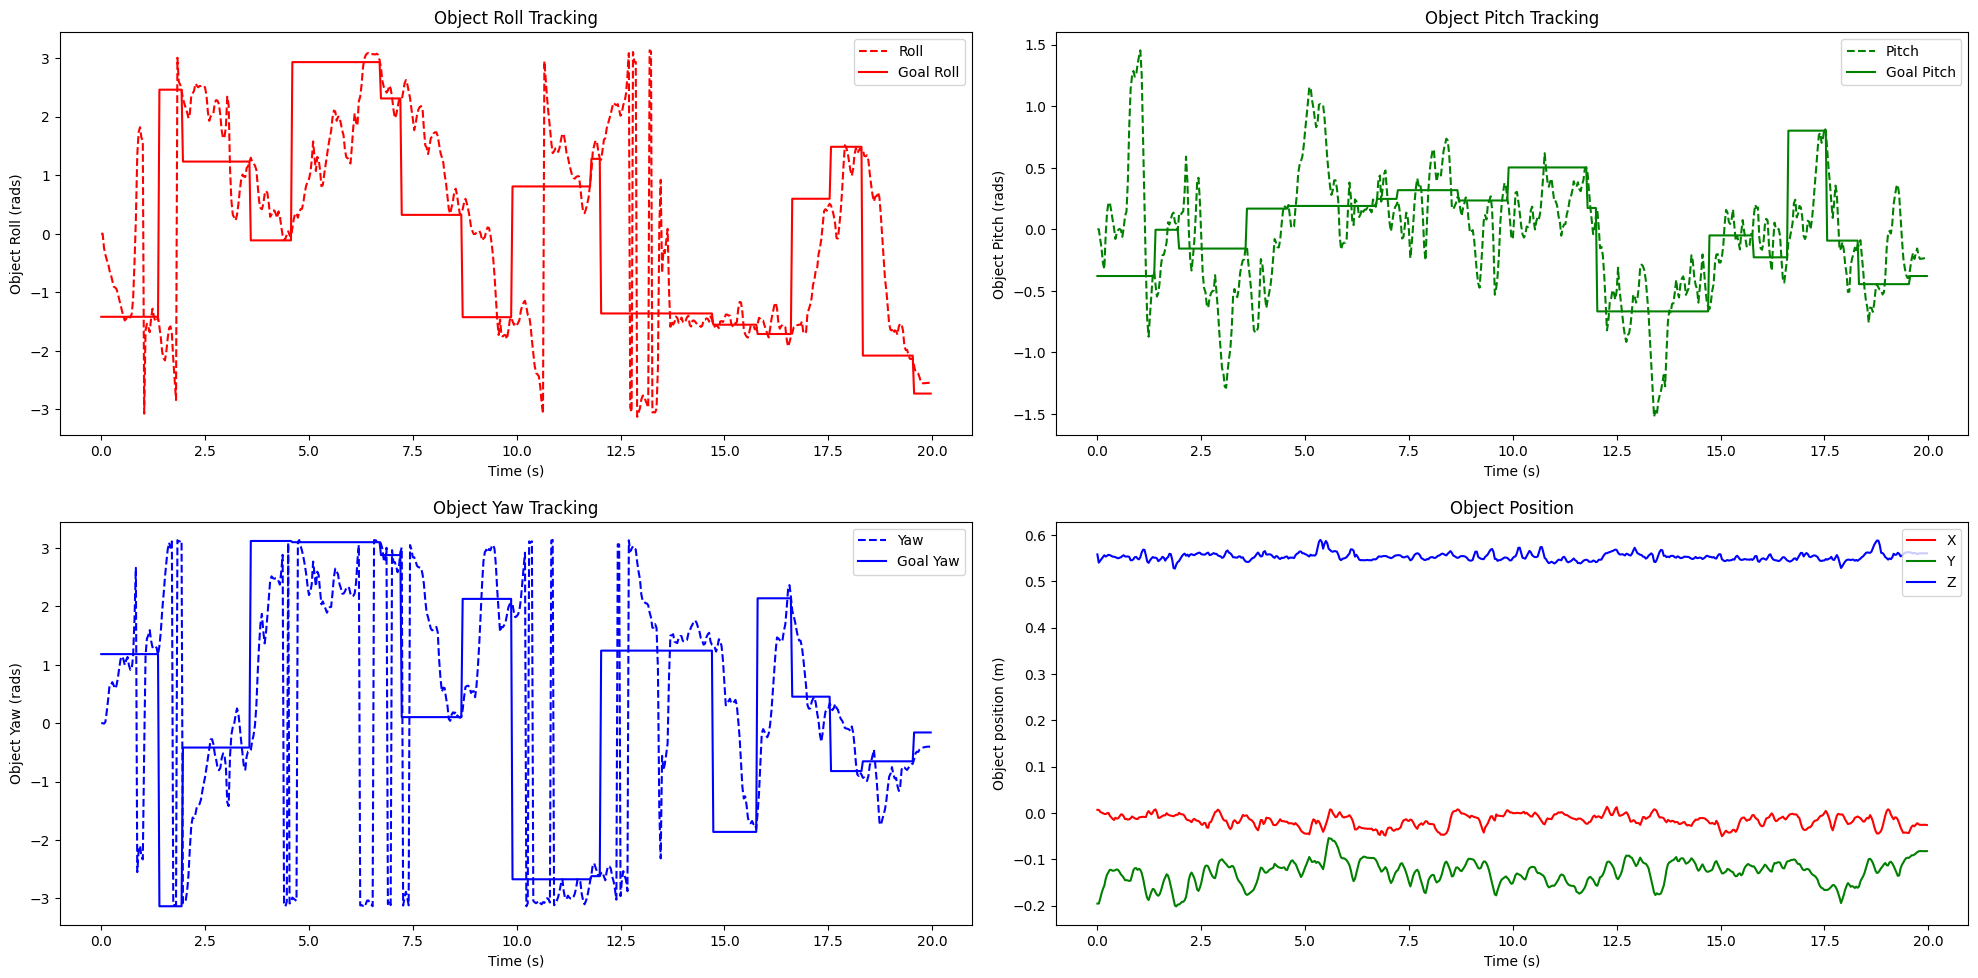

In [78]:
fig, ax = plt.subplots(2,2, figsize=(20, 10))

ax[0,0].plot(time_step[start:stop]/30.0, wrapped_rpy[start:stop, 0], c='r', linestyle='dashed')
ax[0,0].plot(time_step[start:stop]/30.0, wrapped_goal_rpy[start:stop, 0], c='r')
ax[0,0].set_xlabel("Time (s)")
ax[0,0].set_ylabel("Object Roll (rads)")
ax[0,0].legend(['Roll', 'Goal Roll'], loc='upper right')
ax[0,0].set_title("Object Roll Tracking")

ax[0,1].plot(time_step[start:stop]/30.0, wrapped_rpy[start:stop, 1], c='g', linestyle='dashed')
ax[0,1].plot(time_step[start:stop]/30.0, wrapped_goal_rpy[start:stop, 1], c='g')
ax[0,1].set_xlabel("Time (s)")
ax[0,1].set_ylabel("Object Pitch (rads)")
ax[0,1].legend(['Pitch', 'Goal Pitch'], loc='upper right')
ax[0,1].set_title("Object Pitch Tracking")

ax[1,0].plot(time_step[start:stop]/30.0, wrapped_rpy[start:stop, 2], c='b', linestyle='dashed')
ax[1,0].plot(time_step[start:stop]/30.0, wrapped_goal_rpy[start:stop, 2], c='b')
ax[1,0].set_xlabel("Time (s)")
ax[1,0].set_ylabel("Object Yaw (rads)")
ax[1,0].legend(['Yaw', 'Goal Yaw'], loc='upper right')
ax[1,0].set_title("Object Yaw Tracking")

ax[1,1].plot(time_step[start:stop]/30.0, object_pos[start:stop, 0], c='r')
ax[1,1].plot(time_step[start:stop]/30.0, object_pos[start:stop, 1], c='g')
ax[1,1].plot(time_step[start:stop]/30.0, object_pos[start:stop, 2], c='b')
ax[1,1].set_xlabel("Time (s)")
ax[1,1].set_ylabel("Object position (m)")
ax[1,1].legend(['X', 'Y', 'Z'], loc='upper right')
ax[1,1].set_title("Object Position")

plt.tight_layout(pad=1.5)
# plt.savefig(f"{save_folder}/sim_joint_pos_tracking.png")
plt.show()